# **Data Science & Statistical Computing**
## **CheckPoint05 — Random Forest, XGBoost e LightGBM**
### **Wine Quality — Regressão da qualidade de vinhos tintos**

Projeto estruturado segundo o notebook fornecido pelo professor: definição do problema, wrangling, análise exploratória, desenho experimental, baselines, tuning com Grid Search e Optuna, seleção do melhor modelo, teste final e deploy em Streamlit.

## **Identificação dos alunos**

- **Matheus Kitamura Gurther** — RM563205
- **João Guilherme Guida** — RM565244
- **Gustavo Barroso** — RM565705
- **Victor Alves** — RM565723

In [1]:
from pathlib import Path
import json
import re
import time
import warnings
import urllib.request

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_SPLITS = 5

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd()
if not (ROOT / "README.md").exists() and (ROOT.parent / "README.md").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "winequality-red.csv"
MODEL_PATH = ROOT / "models" / "modelo_final.joblib"
DATA_PATH.parent.mkdir(exist_ok=True)
MODEL_PATH.parent.mkdir(exist_ok=True)

print("Pasta do projeto:", ROOT)


Pasta do projeto: D:\Usuario\Downloads\final\wine_quality_checkpoint05_final


---
# **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

### Resposta

**Contexto e problema.** A qualidade de um vinho é influenciada por propriedades químicas mensuráveis, como acidez, teor alcoólico, pH e concentração de sulfatos. O objetivo é investigar se essas propriedades permitem **estimar a nota de qualidade** atribuída ao vinho. Uma solução supervisionada é adequada porque a base apresenta, para cada amostra, atributos físico-químicos e uma nota de qualidade já observada.

**Variável-alvo.** A variável $y$ é `quality`, uma nota sensorial de qualidade. O problema será tratado como **regressão**. Assim, $\hat{y}$ representa a nota de qualidade estimada pelo modelo para uma nova amostra de vinho.

**Base de dados.** Será usada a base **Wine Quality — Red Wine**, publicada na UCI Machine Learning Repository por Cortez et al. A versão de vinho tinto possui **1.599 observações**, 11 variáveis preditoras físico-químicas e 1 variável-alvo. A unidade observacional é uma amostra de vinho tinto Vinho Verde português.

**Critério de sucesso.** A métrica principal será o **MAE (Mean Absolute Error)**, pois mede, na mesma escala da nota de qualidade, o erro absoluto médio das previsões e possui interpretação direta. Como métricas auxiliares serão usados **RMSE** (penaliza mais erros grandes) e **R²** (proporção da variabilidade explicada pelo modelo).

In [2]:
UCI_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

if not DATA_PATH.exists():
    print("Base não encontrada localmente. Tentando baixar da UCI...")
    urllib.request.urlretrieve(UCI_URL, DATA_PATH)

df_original = pd.read_csv(DATA_PATH, sep=";")

print("Dimensões iniciais:", df_original.shape)
display(df_original.head())
display(df_original.describe().T)

Dimensões iniciais: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


,variavel,papel,descricao
0,fixed acidity,preditora,Acidez fixa
1,volatile acidity,preditora,Acidez volátil
2,citric acid,preditora,Ácido cítrico
3,residual sugar,preditora,Açúcar residual
4,chlorides,preditora,Cloretos
5,free sulfur dioxide,preditora,Dióxido de enxofre livre
6,total sulfur dioxide,preditora,Dióxido de enxofre total
7,density,preditora,Densidade
8,pH,preditora,pH
9,sulphates,preditora,Sulfatos


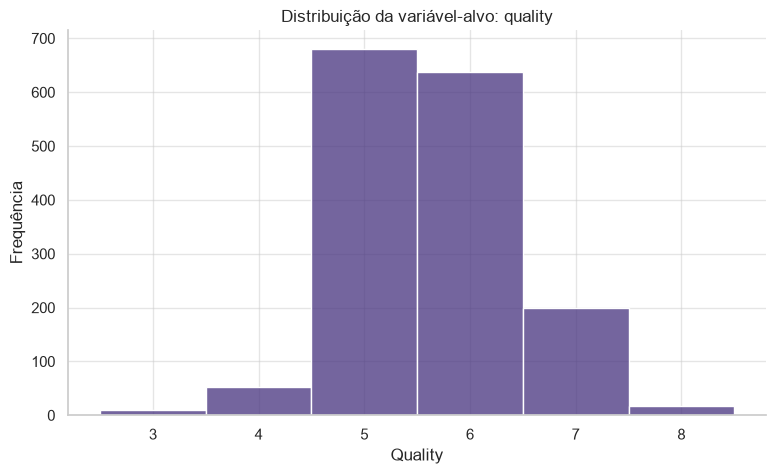

In [3]:
dicionario = pd.DataFrame({
    "variavel": df_original.columns,
    "papel": ["alvo" if c == "quality" else "preditora" for c in df_original.columns],
    "descricao": [
        "Acidez fixa", "Acidez volátil", "Ácido cítrico", "Açúcar residual", "Cloretos",
        "Dióxido de enxofre livre", "Dióxido de enxofre total", "Densidade", "pH",
        "Sulfatos", "Teor alcoólico", "Nota sensorial de qualidade"
    ]
})
display(dicionario)

sns.histplot(df_original["quality"], discrete=True)
plt.title("Distribuição da variável-alvo: quality")
plt.xlabel("Quality")
plt.ylabel("Frequência")
plt.show()

---
# **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

### Resposta

O diagnóstico verificará tipos, valores ausentes, duplicidades e faixas numéricas. Como todas as variáveis são numéricas e a fonte oficial não apresenta valores ausentes, não é necessária imputação. Duplicidades exatas serão removidas para evitar que observações repetidas tenham peso artificial durante a validação. Não serão removidos outliers apenas para melhorar métricas, pois valores extremos podem representar amostras reais e algoritmos de árvores são relativamente robustos a escala e extremos.

In [4]:
print("Tipos de dados:")
display(df_original.dtypes.to_frame("dtype"))

print("Valores ausentes por coluna:")
display(df_original.isna().sum().to_frame("ausentes"))

print("Duplicidades exatas:", df_original.duplicated().sum())
print("Valores mínimo/máximo:")
display(pd.DataFrame({"min": df_original.min(), "max": df_original.max()}))

Tipos de dados:


,dtype
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


Valores ausentes por coluna:


,ausentes
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Duplicidades exatas: 240
Valores mínimo/máximo:


,min,max
fixed acidity,4.60000,15.90000
volatile acidity,0.12000,1.58000
citric acid,0.00000,1.00000
residual sugar,0.90000,15.50000
chlorides,0.01200,0.61100
free sulfur dioxide,1.00000,72.00000
total sulfur dioxide,6.00000,289.00000
density,0.99007,1.00369
pH,2.74000,4.01000
sulphates,0.33000,2.00000


In [5]:
df = df_original.drop_duplicates().reset_index(drop=True)

print("Dimensões após tratamento:", df.shape)
print("Ausências após tratamento:", int(df.isna().sum().sum()))
print("Duplicidades após tratamento:", int(df.duplicated().sum()))

Dimensões após tratamento: (1359, 12)
Ausências após tratamento: 0
Duplicidades após tratamento: 0


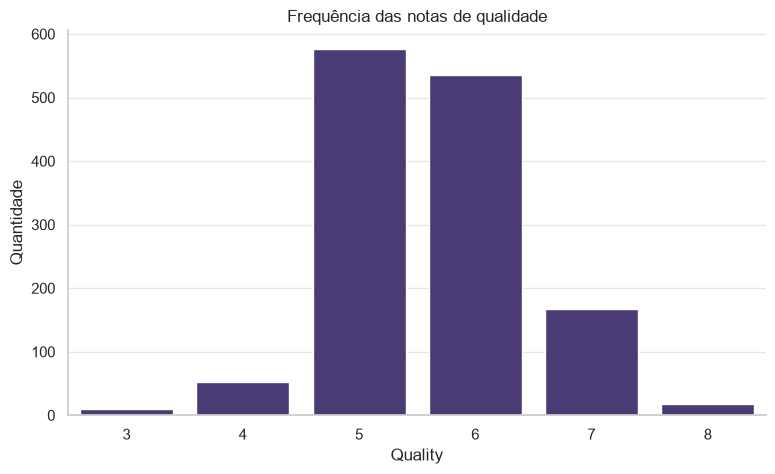

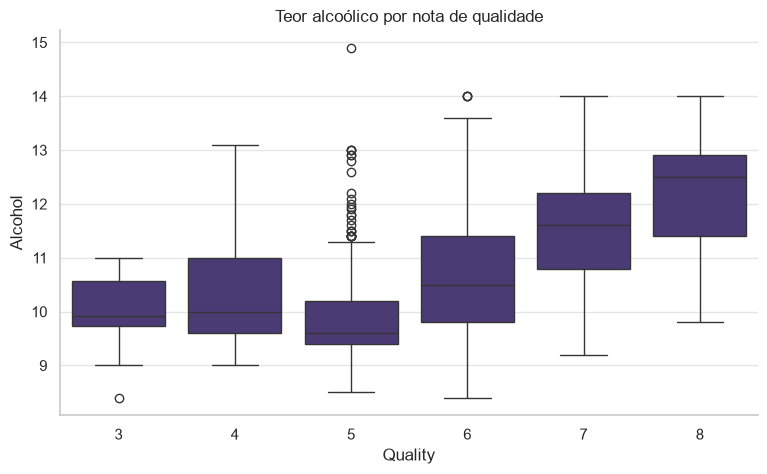

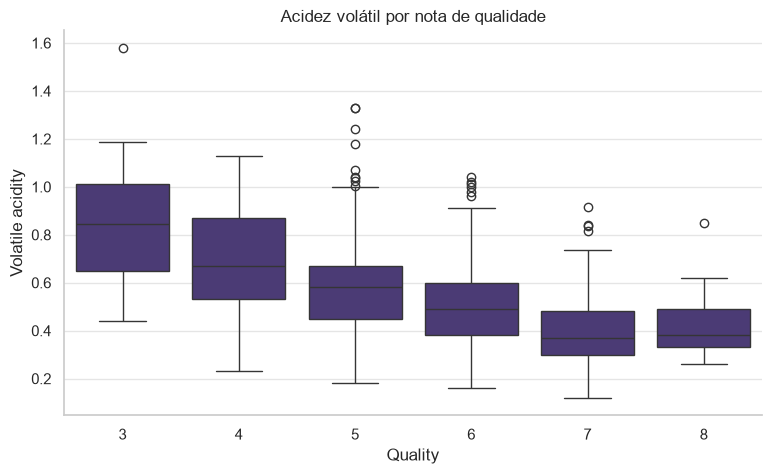

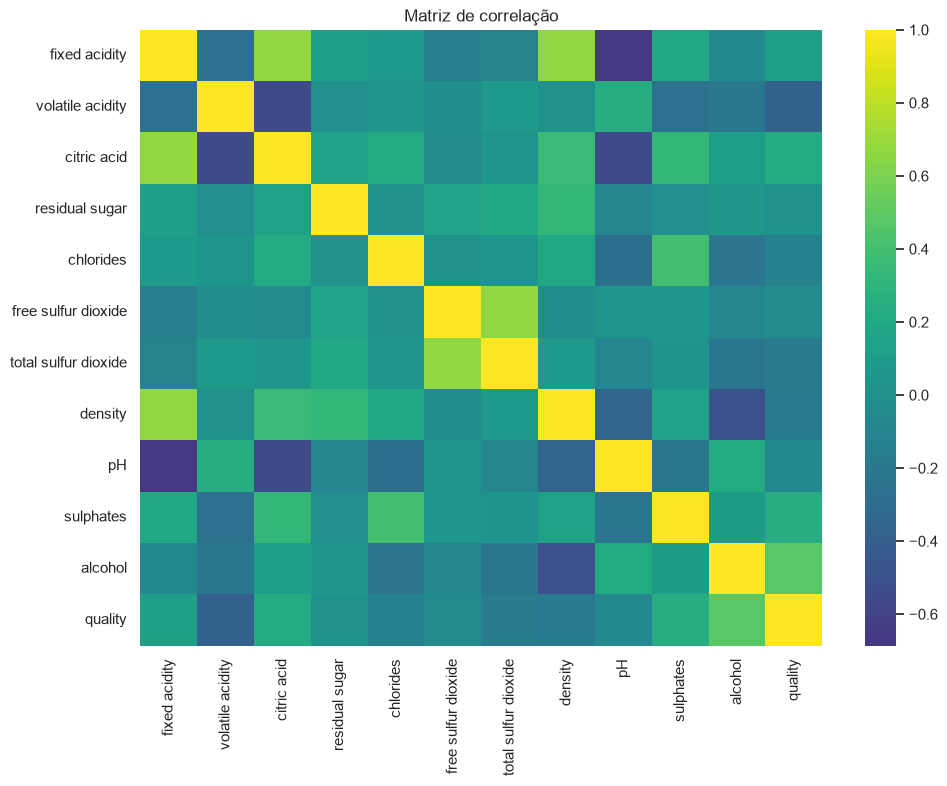

In [6]:
sns.countplot(data=df, x="quality")
plt.title("Frequência das notas de qualidade")
plt.xlabel("Quality")
plt.ylabel("Quantidade")
plt.show()

sns.boxplot(data=df, x="quality", y="alcohol")
plt.title("Teor alcoólico por nota de qualidade")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.show()

sns.boxplot(data=df, x="quality", y="volatile acidity")
plt.title("Acidez volátil por nota de qualidade")
plt.xlabel("Quality")
plt.ylabel("Volatile acidity")
plt.show()

plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="viridis", center=0)
plt.title("Matriz de correlação")
plt.show()

### Interpretação da análise exploratória

A distribuição de `quality` é concentrada principalmente nas notas intermediárias, enquanto notas muito baixas ou muito altas aparecem com menor frequência. Isso indica que prever extremos pode ser mais difícil. O boxplot do teor alcoólico permite verificar uma tendência de maiores valores de `alcohol` em amostras com notas mais altas. Já a `volatile acidity` tende a apresentar relação inversa com a qualidade. A matriz de correlação ajuda a identificar associações lineares, mas não será usada para eliminar variáveis automaticamente, pois os três algoritmos de árvores conseguem capturar relações não lineares e interações.

A base final permanece totalmente numérica; portanto, não será necessário aplicar padronização nem codificação categórica. As transformações aprendidas a partir dos dados não serão feitas fora do conjunto de treino.

---
# **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

### Resposta

Serão utilizadas as **11 variáveis físico-químicas** como atributos de $X$ e `quality` como $y$. Nenhuma coluna funciona como identificador e não existem variáveis posteriores ao evento ou que revelem diretamente a nota, portanto não há exclusões por vazamento de dados.

A separação será de **80% treino e 20% teste**, com `random_state=42`. O conjunto de teste será armazenado e não será consultado até o Exercício 7. Dentro do conjunto de treino será usada **validação cruzada K-Fold com 5 folds, embaralhamento e random_state=42**.

A comparação manterá **MAE** como métrica principal. Para o Scikit-Learn será usada `neg_mean_absolute_error` durante a validação, convertendo o sinal ao apresentar os resultados. As métricas auxiliares serão RMSE e R².

In [7]:
X = df.drop(columns="quality")
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = "neg_mean_absolute_error"

print("X treino:", X_train.shape)
print("X teste (isolado até o Exercício 7):", X_test.shape)
print("y treino:", y_train.shape)
print("y teste:", y_test.shape)
print("Variáveis:", list(X.columns))

X treino: (1087, 11)
X teste (isolado até o Exercício 7): (272, 11)
y treino: (1087,)
y teste: (272,)
Variáveis: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


---
# **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

### Resposta

Nesta etapa são criados três **baselines comparáveis**, sem tuning. Todos recebem os mesmos dados de treino, os mesmos folds de validação e a mesma métrica. O teste continua isolado.

In [8]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def avaliar_baseline(nome, modelo):
    inicio = time.perf_counter()
    modelo.fit(X_train, y_train)
    tempo = time.perf_counter() - inicio

    pred_train = modelo.predict(X_train)
    mae_train = mean_absolute_error(y_train, pred_train)

    scores = -cross_val_score(
        clone(modelo), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )

    return {
        "modelo": nome,
        "configuracao": "Baseline",
        "mae_treino": mae_train,
        "mae_cv": scores.mean(),
        "std_cv": scores.std(),
        "tempo_s": tempo,
        "estimador": modelo,
    }

rf_base = RandomForestRegressor(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
)

xgb_base = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
)

lgbm_base = LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
)

resultados_base = [
    avaliar_baseline("Random Forest", rf_base),
    avaliar_baseline("XGBoost", xgb_base),
    avaliar_baseline("LightGBM", lgbm_base),
]

baseline_df = pd.DataFrame([{k:v for k,v in r.items() if k != "estimador"} for r in resultados_base])
display(baseline_df.sort_values("mae_cv"))

,modelo,configuracao,mae_treino,mae_cv,std_cv,tempo_s
0,Random Forest,Baseline,0.184042,0.506008,0.019605,0.317944
1,XGBoost,Baseline,0.093779,0.513379,0.017901,0.404936
2,LightGBM,Baseline,0.129042,0.527685,0.017743,0.228325


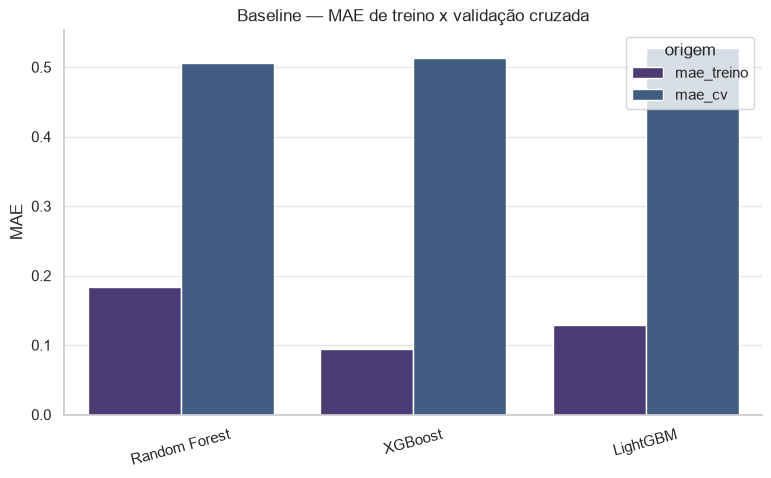

In [9]:
plot_base = baseline_df.melt(
    id_vars="modelo", value_vars=["mae_treino", "mae_cv"],
    var_name="origem", value_name="MAE"
)
sns.barplot(data=plot_base, x="modelo", y="MAE", hue="origem")
plt.title("Baseline — MAE de treino x validação cruzada")
plt.xlabel("")
plt.xticks(rotation=15)
plt.show()

In [10]:
melhor_base = baseline_df.sort_values(["mae_cv", "std_cv"]).iloc[0]
maior_gap_base = baseline_df.assign(
    gap=lambda d: d["mae_cv"] - d["mae_treino"]
).sort_values("gap", ascending=False).iloc[0]

texto_baseline = f"""
### Interpretação dos baselines

Entre os modelos de referência, **{melhor_base['modelo']}** apresentou o menor MAE médio
de validação cruzada (**{melhor_base['mae_cv']:.4f} ± {melhor_base['std_cv']:.4f}**),
sendo portanto o baseline com melhor capacidade de generalização estimada nesta etapa.

A comparação entre treino e validação também deve considerar o gap entre os erros.
O maior gap observado ocorreu em **{maior_gap_base['modelo']}**, com diferença de
**{(maior_gap_base['mae_cv'] - maior_gap_base['mae_treino']):.4f}** entre MAE de validação
e MAE de treino. Quanto maior essa diferença, maior a evidência de sobreajuste.

Esses resultados são apenas de referência: a escolha definitiva será feita após Grid Search e
Optuna, sempre usando somente o conjunto de treino e os mesmos folds de validação cruzada.
"""
display(Markdown(texto_baseline))



### Interpretação dos baselines

Entre os modelos de referência, **Random Forest** apresentou o menor MAE médio
de validação cruzada (**0.5060 ± 0.0196**),
sendo portanto o baseline com melhor capacidade de generalização estimada nesta etapa.

A comparação entre treino e validação também deve considerar o gap entre os erros.
O maior gap observado ocorreu em **XGBoost**, com diferença de
**0.4196** entre MAE de validação
e MAE de treino. Quanto maior essa diferença, maior a evidência de sobreajuste.

Esses resultados são apenas de referência: a escolha definitiva será feita após Grid Search e
Optuna, sempre usando somente o conjunto de treino e os mesmos folds de validação cruzada.


---
# **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

### Resposta

O tuning será realizado **somente sobre `X_train` e `y_train`**. Para cada algoritmo serão executadas duas estratégias:

1. **Grid Search:** explora uma grade discreta e reprodutível de combinações.
2. **Optuna:** explora um espaço mais amplo com 20 trials por modelo, conforme a referência do enunciado.

A métrica permanece MAE e os folds são os mesmos definidos no Exercício 3.

In [11]:
def executar_grid(nome, modelo, param_grid):
    busca = GridSearchCV(
        estimator=modelo,
        param_grid=param_grid,
        scoring=SCORING,
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    inicio = time.perf_counter()
    busca.fit(X_train, y_train)
    tempo = time.perf_counter() - inicio

    idx = busca.best_index_
    return {
        "modelo": nome,
        "configuracao": "Grid Search",
        "mae_treino": -busca.cv_results_["mean_train_score"][idx],
        "mae_cv": -busca.best_score_,
        "std_cv": busca.cv_results_["std_test_score"][idx],
        "tempo_s": tempo,
        "melhores_parametros": busca.best_params_,
        "estimador": busca.best_estimator_,
        "objeto_busca": busca,
    }

rf_grid_params = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

xgb_grid_params = {
    "n_estimators": [200, 500],
    "learning_rate": [0.03, 0.08],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

lgbm_grid_params = {
    "n_estimators": [200, 500],
    "learning_rate": [0.03, 0.08],
    "num_leaves": [15, 31],
    "max_depth": [-1, 10],
}

rf_grid = executar_grid(
    "Random Forest",
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    rf_grid_params,
)
xgb_grid = executar_grid(
    "XGBoost",
    XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1),
    xgb_grid_params,
)
lgbm_grid = executar_grid(
    "LightGBM",
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
    lgbm_grid_params,
)

grid_results = [rf_grid, xgb_grid, lgbm_grid]
grid_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ["estimador","objeto_busca"]} for r in grid_results])
display(grid_df.sort_values("mae_cv"))

,modelo,configuracao,mae_treino,mae_cv,std_cv,tempo_s,melhores_parametros
0,Random Forest,Grid Search,0.274655,0.505116,0.019525,17.133130,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."
1,XGBoost,Grid Search,0.198531,0.508093,0.014614,9.968723,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
2,LightGBM,Grid Search,0.330658,0.513428,0.019733,9.771969,"{'learning_rate': 0.03, 'max_depth': -1, 'n_es..."


In [12]:
N_TRIALS = 20


def avaliar_parametros(modelo):
    scores = -cross_val_score(
        modelo, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1
    )
    return scores.mean(), scores.std()


def objective_rf(trial):
    modelo = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 150, 700, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 24),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    mae, _ = avaliar_parametros(modelo)
    return mae


def objective_xgb(trial):
    modelo = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 150, 700, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 8),
        subsample=trial.suggest_float("subsample", 0.65, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    mae, _ = avaliar_parametros(modelo)
    return mae


def objective_lgbm(trial):
    modelo = LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 150, 700, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 10, 60),
        max_depth=trial.suggest_int("max_depth", 3, 16),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 50),
        subsample=trial.suggest_float("subsample", 0.65, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    mae, _ = avaliar_parametros(modelo)
    return mae


def executar_optuna(nome, objective, construtor):
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    inicio = time.perf_counter()
    study.optimize(objective, n_trials=N_TRIALS)
    tempo = time.perf_counter() - inicio

    best_params = study.best_params
    modelo = construtor(best_params)
    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    mae_train = mean_absolute_error(y_train, pred_train)
    scores = -cross_val_score(modelo, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)

    return {
        "modelo": nome,
        "configuracao": "Optuna",
        "mae_treino": mae_train,
        "mae_cv": scores.mean(),
        "std_cv": scores.std(),
        "tempo_s": tempo,
        "melhores_parametros": best_params,
        "estimador": modelo,
        "study": study,
    }

rf_optuna = executar_optuna(
    "Random Forest", objective_rf,
    lambda p: RandomForestRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1)
)
xgb_optuna = executar_optuna(
    "XGBoost", objective_xgb,
    lambda p: XGBRegressor(**p, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1)
)
lgbm_optuna = executar_optuna(
    "LightGBM", objective_lgbm,
    lambda p: LGBMRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
)

optuna_results = [rf_optuna, xgb_optuna, lgbm_optuna]
optuna_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ["estimador","study"]} for r in optuna_results])
display(optuna_df.sort_values("mae_cv"))

,modelo,configuracao,mae_treino,mae_cv,std_cv,tempo_s,melhores_parametros
0,Random Forest,Optuna,0.262100,0.503262,0.021611,12.188247,"{'n_estimators': 400, 'max_depth': 14, 'min_sa..."
2,LightGBM,Optuna,0.404085,0.507384,0.020888,7.986609,"{'n_estimators': 200, 'learning_rate': 0.02245..."
1,XGBoost,Optuna,0.393935,0.508020,0.015404,6.878262,"{'n_estimators': 200, 'learning_rate': 0.02205..."


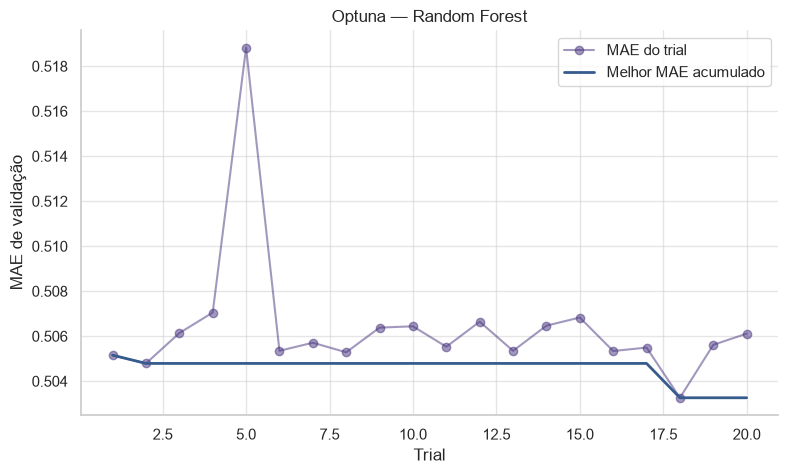

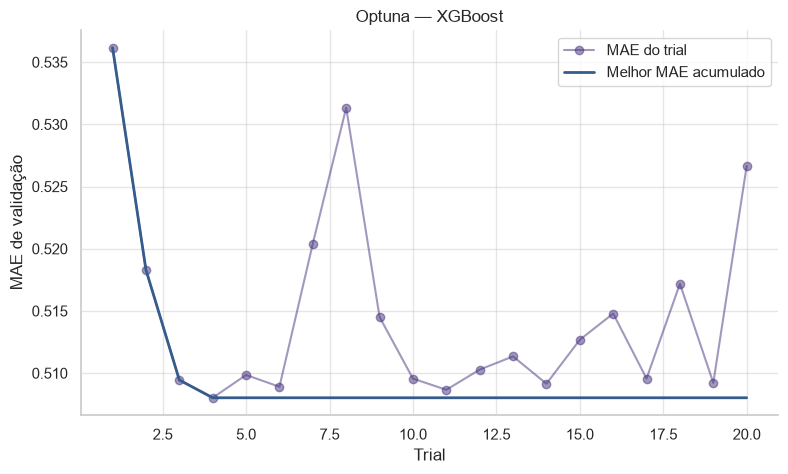

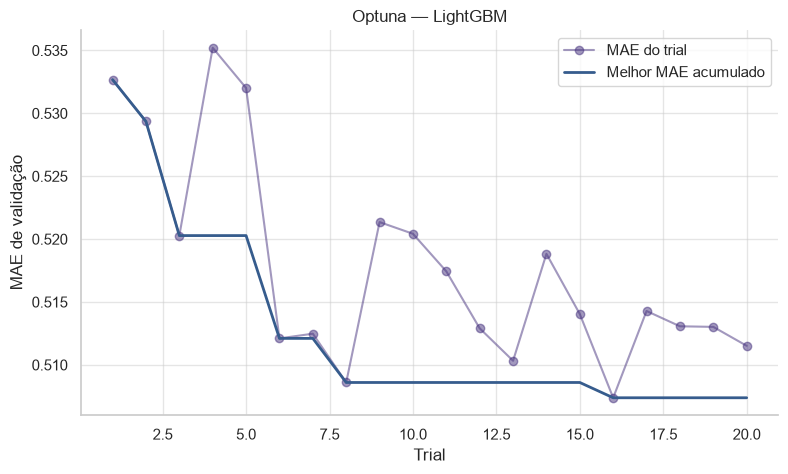

In [13]:
for r in optuna_results:
    valores = [t.value for t in r["study"].trials if t.value is not None]
    melhor_acumulado = np.minimum.accumulate(valores)
    plt.figure()
    plt.plot(range(1, len(valores)+1), valores, marker="o", alpha=0.5, label="MAE do trial")
    plt.plot(range(1, len(valores)+1), melhor_acumulado, linewidth=2, label="Melhor MAE acumulado")
    plt.title(f"Optuna — {r['modelo']}")
    plt.xlabel("Trial")
    plt.ylabel("MAE de validação")
    plt.legend()
    plt.show()

In [14]:
tuning_df = pd.DataFrame([
    {
        "modelo": r["modelo"],
        "configuracao": r["configuracao"],
        "mae_cv": r["mae_cv"],
        "std_cv": r["std_cv"],
        "tempo": r.get("tempo", np.nan),
    }
    for r in (grid_results + optuna_results)
]).sort_values(["modelo", "mae_cv"])

display(tuning_df)

linhas = []
for modelo in tuning_df["modelo"].unique():
    sub = tuning_df[tuning_df["modelo"] == modelo].sort_values("mae_cv")
    melhor = sub.iloc[0]
    outra = sub.iloc[1]
    ganho = outra["mae_cv"] - melhor["mae_cv"]
    linhas.append(
        f"- **{modelo}:** {melhor['configuracao']} obteve o menor MAE CV "
        f"({melhor['mae_cv']:.4f} ± {melhor['std_cv']:.4f}). "
        f"A diferença para {outra['configuracao']} foi de {ganho:.4f} MAE."
    )

melhor_tuning = tuning_df.iloc[0]
texto_tuning = """
### Comparação Grid Search x Optuna

""" + "\n".join(linhas) + f"""

Considerando todos os ajustes, a melhor combinação nesta etapa foi
**{melhor_tuning['modelo']} — {melhor_tuning['configuracao']}**, com MAE médio de validação
de **{melhor_tuning['mae_cv']:.4f}**.

A decisão final, entretanto, não será baseada apenas na menor diferença numérica: também serão
considerados o desvio-padrão entre folds, o gap treino–validação, a curva de aprendizado e a
complexidade da configuração.
"""
display(Markdown(texto_tuning))


,modelo,configuracao,mae_cv,std_cv,tempo
5,LightGBM,Optuna,0.507384,0.020888,NaN
2,LightGBM,Grid Search,0.513428,0.019733,NaN
3,Random Forest,Optuna,0.503262,0.021611,NaN
0,Random Forest,Grid Search,0.505116,0.019525,NaN
4,XGBoost,Optuna,0.508020,0.015404,NaN
1,XGBoost,Grid Search,0.508093,0.014614,NaN



### Comparação Grid Search x Optuna

- **LightGBM:** Optuna obteve o menor MAE CV (0.5074 ± 0.0209). A diferença para Grid Search foi de 0.0060 MAE.
- **Random Forest:** Optuna obteve o menor MAE CV (0.5033 ± 0.0216). A diferença para Grid Search foi de 0.0019 MAE.
- **XGBoost:** Optuna obteve o menor MAE CV (0.5080 ± 0.0154). A diferença para Grid Search foi de 0.0001 MAE.

Considerando todos os ajustes, a melhor combinação nesta etapa foi
**LightGBM — Optuna**, com MAE médio de validação
de **0.5074**.

A decisão final, entretanto, não será baseada apenas na menor diferença numérica: também serão
considerados o desvio-padrão entre folds, o gap treino–validação, a curva de aprendizado e a
complexidade da configuração.


---
# **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

### Resposta

A escolha será feita apenas com dados de treino e validação cruzada. Serão comparadas as **nove configurações obrigatórias**: baseline, melhor Grid Search e melhor Optuna para Random Forest, XGBoost e LightGBM. A configuração com menor MAE de validação será a candidata principal, mas serão considerados também o desvio entre folds, o gap treino–validação e a complexidade.

In [15]:
base_records = resultados_base
all_results = base_records + grid_results + optuna_results

comparacao = pd.DataFrame([
    {k:v for k,v in r.items() if k not in ["estimador", "objeto_busca", "study", "melhores_parametros"]}
    for r in all_results
])
comparacao["gap_overfitting"] = comparacao["mae_cv"] - comparacao["mae_treino"]
comparacao = comparacao.sort_values(["mae_cv", "std_cv"]).reset_index(drop=True)

display(comparacao)

# Seleção automática: menor MAE CV; em empate prático, menor std_cv.
best_row = comparacao.iloc[0]
melhor_resultado = next(
    r for r in all_results
    if r["modelo"] == best_row["modelo"] and r["configuracao"] == best_row["configuracao"]
)
modelo_final = clone(melhor_resultado["estimador"])

print("Modelo escolhido:", best_row["modelo"])
print("Configuração:", best_row["configuracao"])
print("MAE CV:", round(best_row["mae_cv"], 4))
print("Desvio-padrão CV:", round(best_row["std_cv"], 4))
print("Gap treino-CV:", round(best_row["gap_overfitting"], 4))

,modelo,configuracao,mae_treino,mae_cv,std_cv,tempo_s,gap_overfitting
0,Random Forest,Optuna,0.262100,0.503262,0.021611,12.188247,0.241163
1,Random Forest,Grid Search,0.274655,0.505116,0.019525,17.133130,0.230461
2,Random Forest,Baseline,0.184042,0.506008,0.019605,0.317944,0.321967
3,LightGBM,Optuna,0.404085,0.507384,0.020888,7.986609,0.103300
4,XGBoost,Optuna,0.393935,0.508020,0.015404,6.878262,0.114085
5,XGBoost,Grid Search,0.198531,0.508093,0.014614,9.968723,0.309562
6,XGBoost,Baseline,0.093779,0.513379,0.017901,0.404936,0.419600
7,LightGBM,Grid Search,0.330658,0.513428,0.019733,9.771969,0.182769
8,LightGBM,Baseline,0.129042,0.527685,0.017743,0.228325,0.398643


Modelo escolhido: Random Forest
Configuração: Optuna
MAE CV: 0.5033
Desvio-padrão CV: 0.0216
Gap treino-CV: 0.2412


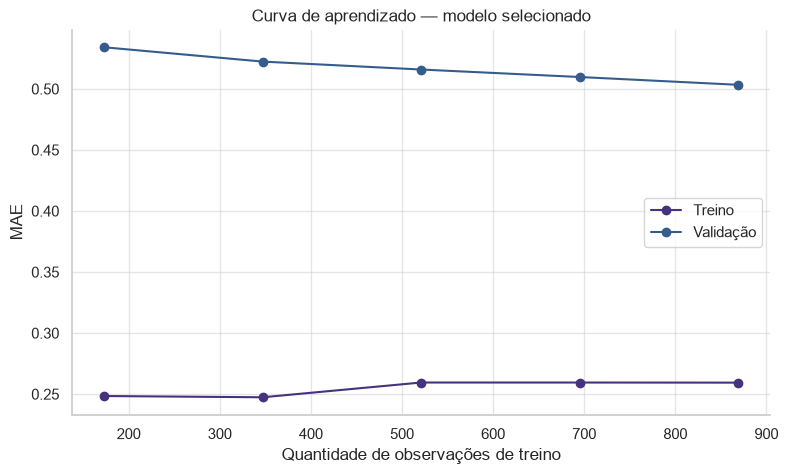

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    modelo_final,
    X_train,
    y_train,
    cv=cv,
    scoring=SCORING,
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1,
)

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

plt.plot(train_sizes, train_mae, marker="o", label="Treino")
plt.plot(train_sizes, val_mae, marker="o", label="Validação")
plt.title("Curva de aprendizado — modelo selecionado")
plt.xlabel("Quantidade de observações de treino")
plt.ylabel("MAE")
plt.legend()
plt.show()

,importancia
alcohol,0.209793
sulphates,0.141131
volatile acidity,0.122260
density,0.084392
total sulfur dioxide,0.080473
chlorides,0.072045
citric acid,0.068743
fixed acidity,0.058632
pH,0.058385
residual sugar,0.055427


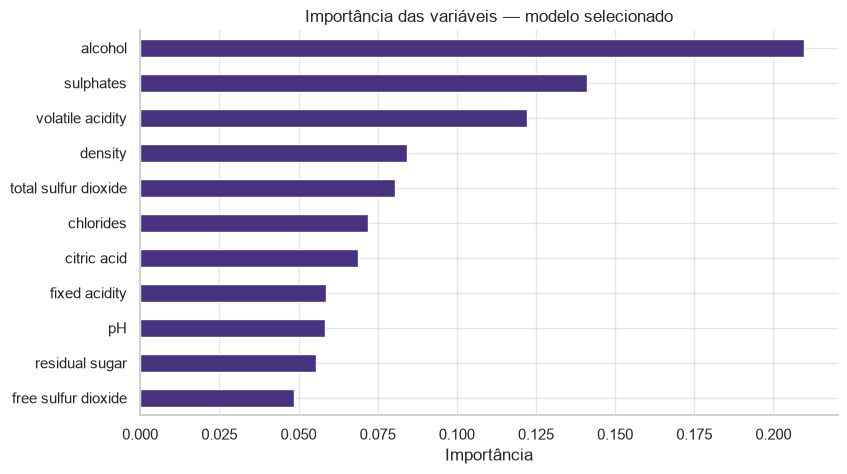

In [17]:
modelo_interpretacao = clone(modelo_final)
modelo_interpretacao.fit(X_train, y_train)

if hasattr(modelo_interpretacao, "feature_importances_"):
    importancias = pd.Series(
        modelo_interpretacao.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)

    display(importancias.to_frame("importancia"))
    importancias.sort_values().plot(kind="barh")
    plt.title("Importância das variáveis — modelo selecionado")
    plt.xlabel("Importância")
    plt.show()


### Interpretação de overfitting/underfitting

A configuração selecionada foi **Random Forest — Optuna**.
Seu MAE médio de validação cruzada foi **0.5033 ± 0.0216**,
enquanto o MAE de treino foi **0.2621**.

O gap `MAE_CV - MAE_treino` foi de **0.2412**.
Na maior fração da curva de aprendizado, a diferença entre validação e treino ficou em
**0.2440**. Com base nesses valores, há evidência de **sobreajuste moderado**, pois o erro de treino permanece sensivelmente menor que o erro de validação.

Essa conclusão usa somente dados de treino e validação cruzada; o conjunto de teste continua
isolado e será utilizado apenas no Exercício 7.


Desempenho out-of-fold no treino — MAE: 0.5033 | RMSE: 0.6525 | R²: 0.3637


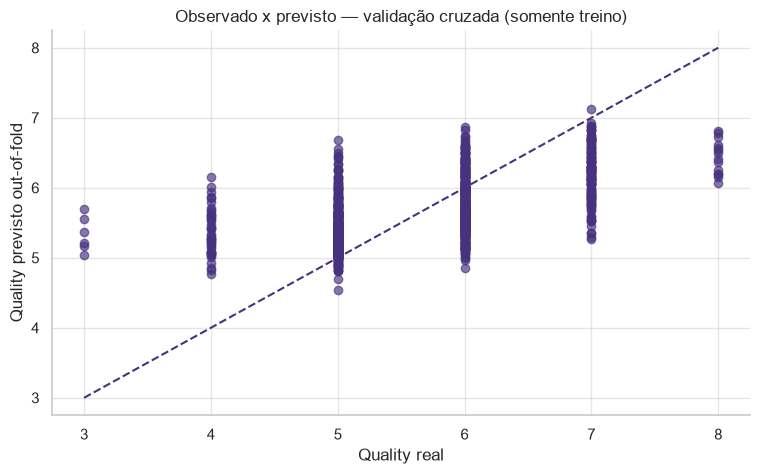

In [18]:
gap_final = float(best_row["gap_overfitting"])
ultimo_gap_curva = float(val_mae[-1] - train_mae[-1])

if gap_final > 0.15 or ultimo_gap_curva > 0.15:
    diagnostico = (
        "há evidência de **sobreajuste moderado**, pois o erro de treino permanece "
        "sensivelmente menor que o erro de validação."
    )
elif best_row["mae_cv"] > 0.80 and abs(gap_final) < 0.08:
    diagnostico = (
        "há possível **underfitting**, pois treino e validação apresentam erros próximos, "
        "mas em patamar relativamente elevado."
    )
else:
    diagnostico = (
        "o comportamento é compatível com **boa generalização**, pois treino e validação "
        "mantêm erros relativamente próximos e a curva de aprendizado tende à convergência."
    )

texto_overfit = f"""
### Interpretação de overfitting/underfitting

A configuração selecionada foi **{best_row['modelo']} — {best_row['configuracao']}**.
Seu MAE médio de validação cruzada foi **{best_row['mae_cv']:.4f} ± {best_row['std_cv']:.4f}**,
enquanto o MAE de treino foi **{best_row['mae_treino']:.4f}**.

O gap `MAE_CV - MAE_treino` foi de **{gap_final:.4f}**.
Na maior fração da curva de aprendizado, a diferença entre validação e treino ficou em
**{ultimo_gap_curva:.4f}**. Com base nesses valores, {diagnostico}

Essa conclusão usa somente dados de treino e validação cruzada; o conjunto de teste continua
isolado e será utilizado apenas no Exercício 7.
"""
display(Markdown(texto_overfit))

y_oof = cross_val_predict(
    clone(modelo_final),
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

oof_mae = mean_absolute_error(y_train, y_oof)
oof_rmse = rmse(y_train, y_oof)
oof_r2 = r2_score(y_train, y_oof)

print(f"Desempenho out-of-fold no treino — MAE: {oof_mae:.4f} | RMSE: {oof_rmse:.4f} | R²: {oof_r2:.4f}")

plt.scatter(y_train, y_oof, alpha=0.65)
lim_min = min(float(y_train.min()), float(np.min(y_oof)))
lim_max = max(float(y_train.max()), float(np.max(y_oof)))
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")
plt.title("Observado x previsto — validação cruzada (somente treino)")
plt.xlabel("Quality real")
plt.ylabel("Quality previsto out-of-fold")
plt.show()


---
# **Exercício 7 — Teste final, consistência, GitHub e Streamlit — 1,5 ponto**

### Resposta

**Somente nesta etapa o conjunto de teste será utilizado.** O modelo selecionado no Exercício 6 será treinado novamente usando todo o conjunto de treino e avaliado uma única vez em `X_test`/`y_test`. Depois serão analisadas cinco observações do teste e o artefato será salvo para uso no Streamlit.

In [19]:
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = rmse(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"MAE teste : {mae_test:.4f}")
print(f"RMSE teste: {rmse_test:.4f}")
print(f"R² teste  : {r2_test:.4f}")
print(f"MAE CV esperado: {best_row['mae_cv']:.4f} ± {best_row['std_cv']:.4f}")

MAE teste : 0.4713
RMSE teste: 0.6174
R² teste  : 0.4619
MAE CV esperado: 0.5033 ± 0.0216


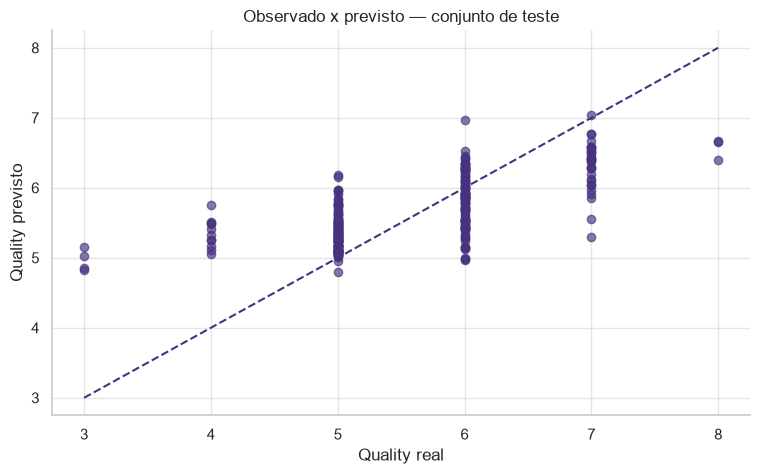

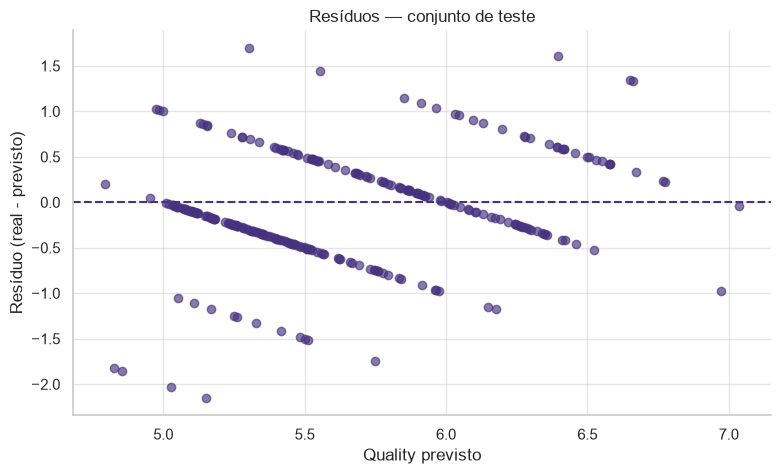


### Interpretação do teste final

O modelo **Random Forest — Optuna** obteve no conjunto de teste:

- **MAE:** 0.4713
- **RMSE:** 0.6174
- **R²:** 0.4619

Durante o desenvolvimento, o MAE médio de validação cruzada foi
**0.5033 ± 0.0216**.
A diferença entre o MAE de teste e o MAE médio de validação foi de **-0.0320**.

O MAE do teste foi menor que o MAE médio de validação por uma diferença superior ao desvio-padrão entre folds. O resultado é favorável, mas deve ser interpretado com cautela por representar uma única partição de teste.

Os gráficos observado × previsto e de resíduos complementam a análise quantitativa e ajudam a
identificar dispersão, tendências sistemáticas e casos de maior dificuldade.


In [20]:
plt.scatter(y_test, y_pred, alpha=0.65)
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--")
plt.title("Observado x previsto — conjunto de teste")
plt.xlabel("Quality real")
plt.ylabel("Quality previsto")
plt.show()

residuos = y_test - y_pred
plt.scatter(y_pred, residuos, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.title("Resíduos — conjunto de teste")
plt.xlabel("Quality previsto")
plt.ylabel("Resíduo (real - previsto)")
plt.show()

dif_mae = mae_test - float(best_row["mae_cv"])
limite_esperado = float(best_row["std_cv"])

if abs(dif_mae) <= limite_esperado:
    avaliacao_generalizacao = (
        "O MAE do teste ficou dentro de aproximadamente um desvio-padrão do MAE médio da "
        "validação cruzada, indicando desempenho final compatível com o observado durante o desenvolvimento."
    )
elif dif_mae > 0:
    avaliacao_generalizacao = (
        "O MAE do teste foi maior que o MAE médio de validação por uma diferença superior ao "
        "desvio-padrão entre folds. Isso sugere perda de desempenho no conjunto não visto e deve ser "
        "mencionado como limitação de generalização."
    )
else:
    avaliacao_generalizacao = (
        "O MAE do teste foi menor que o MAE médio de validação por uma diferença superior ao "
        "desvio-padrão entre folds. O resultado é favorável, mas deve ser interpretado com cautela por "
        "representar uma única partição de teste."
    )

texto_teste = f"""
### Interpretação do teste final

O modelo **{best_row['modelo']} — {best_row['configuracao']}** obteve no conjunto de teste:

- **MAE:** {mae_test:.4f}
- **RMSE:** {rmse_test:.4f}
- **R²:** {r2_test:.4f}

Durante o desenvolvimento, o MAE médio de validação cruzada foi
**{best_row['mae_cv']:.4f} ± {best_row['std_cv']:.4f}**.
A diferença entre o MAE de teste e o MAE médio de validação foi de **{dif_mae:+.4f}**.

{avaliacao_generalizacao}

Os gráficos observado × previsto e de resíduos complementam a análise quantitativa e ajudam a
identificar dispersão, tendências sistemáticas e casos de maior dificuldade.
"""
display(Markdown(texto_teste))


In [21]:
consistencia = X_test.copy()
consistencia["y_real"] = y_test
consistencia["y_previsto"] = y_pred
consistencia["erro_individual"] = consistencia["y_real"] - consistencia["y_previsto"]
consistencia["erro_absoluto"] = consistencia["erro_individual"].abs()

idx_facil = consistencia.nsmallest(3, "erro_absoluto").index
idx_dificil = consistencia.nlargest(2, "erro_absoluto").index
idx_exibir = list(dict.fromkeys(list(idx_facil) + list(idx_dificil)))[:5]

teste_consistencia = consistencia.loc[idx_exibir].copy()
display(teste_consistencia)

caso_facil = teste_consistencia.nsmallest(1, "erro_absoluto").iloc[0]
caso_dificil = teste_consistencia.nlargest(1, "erro_absoluto").iloc[0]

texto_consistencia = f"""
### Interpretação do teste de consistência

Foram selecionadas cinco observações que não participaram do treinamento, incluindo casos com
erro baixo e casos mais difíceis.

O caso com menor erro absoluto apresentou `quality` real **{caso_facil['y_real']:.0f}**,
previsão **{caso_facil['y_previsto']:.3f}** e erro absoluto **{caso_facil['erro_absoluto']:.3f}**.

O caso mais difícil apresentou `quality` real **{caso_dificil['y_real']:.0f}**,
previsão **{caso_dificil['y_previsto']:.3f}** e erro absoluto **{caso_dificil['erro_absoluto']:.3f}**.

A comparação mostra que o modelo produz estimativas coerentes para parte das observações,
mas mantém erros maiores em alguns perfis, o que é esperado em um problema de regressão com
variabilidade sensorial e concentração de notas intermediárias.
"""
display(Markdown(texto_consistencia))


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,y_real,y_previsto,erro_individual,erro_absoluto
513,6.6,0.390,0.49,1.7,0.070,23.0,149.0,0.99220,3.12,0.50,11.5,6,6.002425,-0.002425,0.002425
552,9.6,0.880,0.28,2.4,0.086,30.0,147.0,0.99790,3.24,0.53,9.4,5,5.009633,-0.009633,0.009633
1233,11.7,0.450,0.63,2.2,0.073,7.0,23.0,0.99974,3.21,0.69,10.9,6,6.010130,-0.010130,0.010130
1245,7.3,0.980,0.05,2.1,0.061,20.0,49.0,0.99705,3.31,0.55,9.7,3,5.149701,-2.149701,2.149701
1253,7.1,0.875,0.05,5.7,0.082,3.0,14.0,0.99808,3.40,0.52,10.2,3,5.026230,-2.026230,2.026230



### Interpretação do teste de consistência

Foram selecionadas cinco observações que não participaram do treinamento, incluindo casos com
erro baixo e casos mais difíceis.

O caso com menor erro absoluto apresentou `quality` real **6**,
previsão **6.002** e erro absoluto **0.002**.

O caso mais difícil apresentou `quality` real **3**,
previsão **5.150** e erro absoluto **2.150**.

A comparação mostra que o modelo produz estimativas coerentes para parte das observações,
mas mantém erros maiores em alguns perfis, o que é esperado em um problema de regressão com
variabilidade sensorial e concentração de notas intermediárias.


In [22]:
joblib.dump(modelo_final, MODEL_PATH)
print("Modelo salvo em:", MODEL_PATH)

modelo_recarregado = joblib.load(MODEL_PATH)
linha_paridade = teste_consistencia.iloc[[0]][X.columns]
prev_notebook = float(modelo_final.predict(linha_paridade)[0])
prev_artefato = float(modelo_recarregado.predict(linha_paridade)[0])

print("Previsão no notebook:", prev_notebook)
print("Previsão após recarregar o artefato:", prev_artefato)
print("Paridade:", np.isclose(prev_notebook, prev_artefato))

METADATA_PATH = ROOT / "models" / "model_info.json"

metadata = {
    "modelo": str(best_row["modelo"]),
    "configuracao": str(best_row["configuracao"]),
    "mae_treino": float(best_row["mae_treino"]),
    "mae_cv": float(best_row["mae_cv"]),
    "std_cv": float(best_row["std_cv"]),
    "gap_treino_cv": float(best_row["gap_overfitting"]),
    "mae_teste": float(mae_test),
    "rmse_teste": float(rmse_test),
    "r2_teste": float(r2_test),
    "paridade": {
        "entrada": {col: float(linha_paridade.iloc[0][col]) for col in X.columns},
        "quality_real": float(teste_consistencia.iloc[0]["y_real"]),
        "previsao_notebook": float(prev_notebook),
    },
}

METADATA_PATH.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("Metadados do modelo salvos em:", METADATA_PATH)

README_PATH = ROOT / "README.md"
if README_PATH.exists():
    conteudo = README_PATH.read_text(encoding="utf-8")
    inicio = "<!-- RESULTADOS_INICIO -->"
    fim = "<!-- RESULTADOS_FIM -->"

    bloco = f"""{inicio}
## Resultados finais

- **Modelo selecionado:** {best_row['modelo']}
- **Estratégia/configuração:** {best_row['configuracao']}
- **MAE de treino:** {best_row['mae_treino']:.4f}
- **MAE de validação cruzada:** {best_row['mae_cv']:.4f} ± {best_row['std_cv']:.4f}
- **Gap treino–validação:** {best_row['gap_overfitting']:.4f}
- **MAE no teste:** {mae_test:.4f}
- **RMSE no teste:** {rmse_test:.4f}
- **R² no teste:** {r2_test:.4f}

O modelo final foi escolhido **antes de consultar o conjunto de teste**, com base no desempenho
de validação cruzada, estabilidade entre folds, gap treino–validação e análise da curva de aprendizado.
O conjunto de teste foi utilizado uma única vez na avaliação final.
{fim}"""

    padrao = re.compile(
        re.escape(inicio) + r".*?" + re.escape(fim),
        flags=re.DOTALL
    )

    if padrao.search(conteudo):
        conteudo = padrao.sub(bloco, conteudo)
    else:
        conteudo += "\n\n" + bloco + "\n"

    README_PATH.write_text(conteudo, encoding="utf-8")
    print("README atualizado automaticamente com os resultados finais.")


Modelo salvo em: D:\Usuario\Downloads\final\wine_quality_checkpoint05_final\models\modelo_final.joblib
Previsão no notebook: 6.0024245754245715
Previsão após recarregar o artefato: 6.002424575424575
Paridade: True
Metadados do modelo salvos em: D:\Usuario\Downloads\final\wine_quality_checkpoint05_final\models\model_info.json
README atualizado automaticamente com os resultados finais.


In [23]:
URL_GITHUB = ""
URL_STREAMLIT = ""

print("GitHub:", URL_GITHUB or "PENDENTE")
print("Streamlit:", URL_STREAMLIT or "PENDENTE")

README_PATH = ROOT / "README.md"
if README_PATH.exists():
    conteudo = README_PATH.read_text(encoding="utf-8")
    inicio = "<!-- LINKS_INICIO -->"
    fim = "<!-- LINKS_FIM -->"

    github_md = URL_GITHUB if URL_GITHUB else "PENDENTE"
    streamlit_md = URL_STREAMLIT if URL_STREAMLIT else "PENDENTE"

    bloco_links = f"""{inicio}
## Links da entrega

- **GitHub:** {github_md}
- **Streamlit:** {streamlit_md}
{fim}"""

    padrao_links = re.compile(
        re.escape(inicio) + r".*?" + re.escape(fim),
        flags=re.DOTALL
    )

    if padrao_links.search(conteudo):
        conteudo = padrao_links.sub(bloco_links, conteudo)
    else:
        conteudo += "\n\n" + bloco_links + "\n"

    README_PATH.write_text(conteudo, encoding="utf-8")
    print("README atualizado com os links informados.")


GitHub: PENDENTE
Streamlit: PENDENTE
README atualizado com os links informados.


In [25]:
texto_conclusao = f"""
### Conclusão

O projeto comparou **Random Forest, XGBoost e LightGBM** sob o mesmo protocolo experimental,
mantendo o conjunto de teste isolado durante seleção, comparação e tuning.

A configuração promovida a modelo final foi **{best_row['modelo']} — {best_row['configuracao']}**,
com MAE médio de validação cruzada de **{best_row['mae_cv']:.4f} ± {best_row['std_cv']:.4f}**.
No conjunto de teste, o modelo obteve **MAE = {mae_test:.4f}**, **RMSE = {rmse_test:.4f}**
e **R² = {r2_test:.4f}**.

O teste de consistência evidenciou tanto previsões muito próximas do valor real quanto observações
mais difíceis, enquanto o teste de paridade confirmou que o artefato salvo reproduz a mesma previsão
gerada no notebook.

A aplicação Streamlit utiliza exatamente `models/modelo_final.joblib` e os metadados registrados em
`models/model_info.json`, preservando a correspondência entre desenvolvimento e deploy.
"""
display(Markdown(texto_conclusao))



### Conclusão

O projeto comparou **Random Forest, XGBoost e LightGBM** sob o mesmo protocolo experimental,
mantendo o conjunto de teste isolado durante seleção, comparação e tuning.

A configuração promovida a modelo final foi **Random Forest — Optuna**,
com MAE médio de validação cruzada de **0.5033 ± 0.0216**.
No conjunto de teste, o modelo obteve **MAE = 0.4713**, **RMSE = 0.6174**
e **R² = 0.4619**.

O teste de consistência evidenciou tanto previsões muito próximas do valor real quanto observações
mais difíceis, enquanto o teste de paridade confirmou que o artefato salvo reproduz a mesma previsão
gerada no notebook.

A aplicação Streamlit utiliza exatamente `models/modelo_final.joblib` e os metadados registrados em
`models/model_info.json`, preservando a correspondência entre desenvolvimento e deploy.
